In [1]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from data import get_physics_dataset, UnifiedDatasetWrapper


def form_dataset(train: bool = False) -> torch.utils.data.Dataset:
    data_filepath = 'data_demo/caloGAN_case11_5D_120K.npz'
    return UnifiedDatasetWrapper(get_physics_dataset(data_filepath, train=train))

data = form_dataset(train=True)
val_data = form_dataset(train=False)
dl = torch.utils.data.DataLoader(data, batch_size=32)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32)

In [3]:
for i in val_loader:
    energy = i[0]
    point = i[1][0]
    momentum = i[1][1]
    print(i[0].shape)
    print(i[1][0].shape)
    print(i[1][1].shape)
    break

torch.Size([32, 1, 30, 30])
torch.Size([32, 2])
torch.Size([32, 3])


In [4]:
from diffusion import DiffusionModel

dm = DiffusionModel(100, 16)
dm.load_state_dict(torch.load('checkpoints/t100.pt', map_location=torch.device('cpu')))
dm.eval();

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

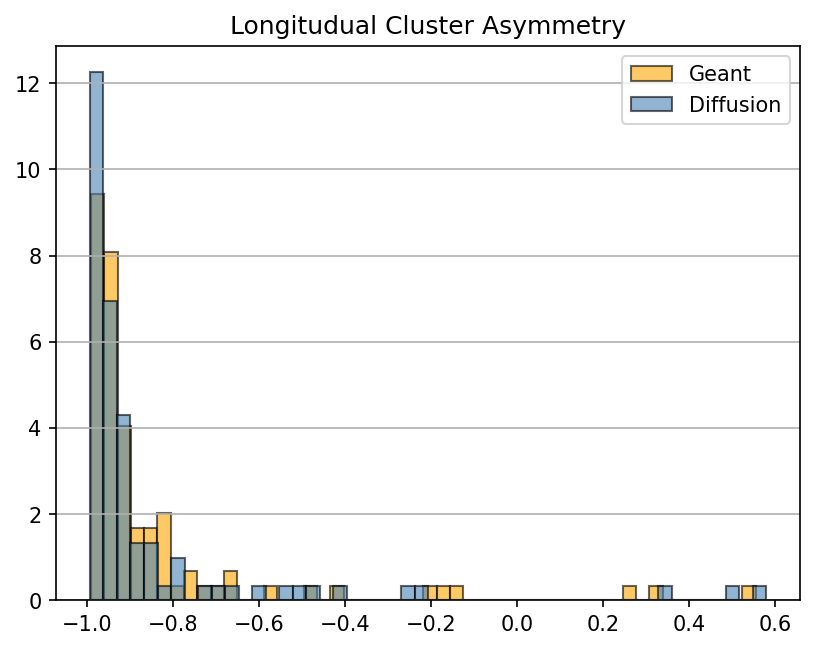

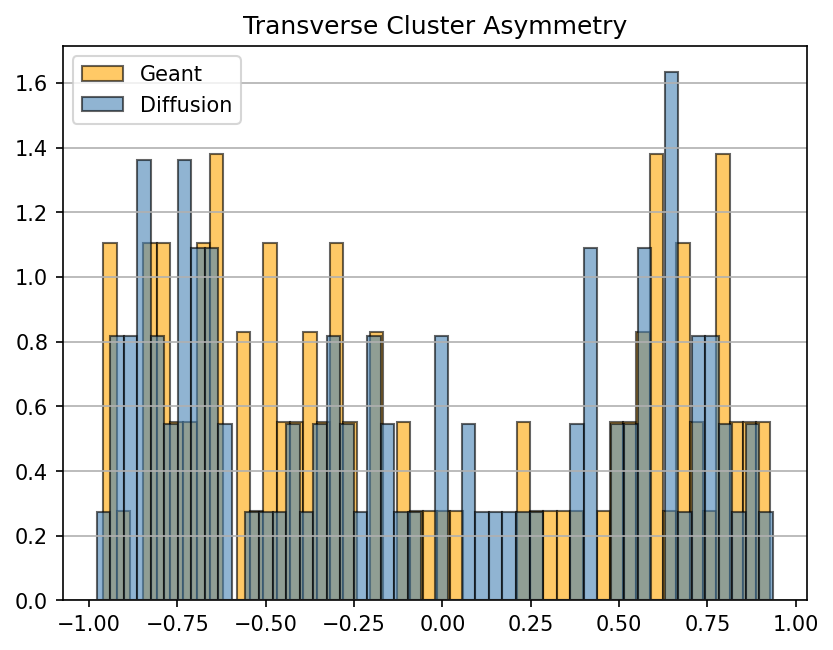

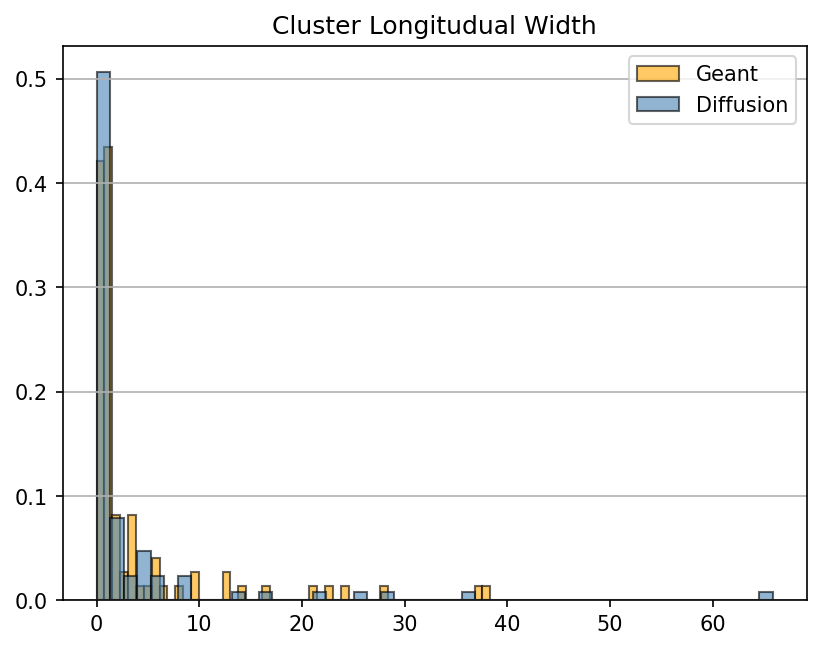

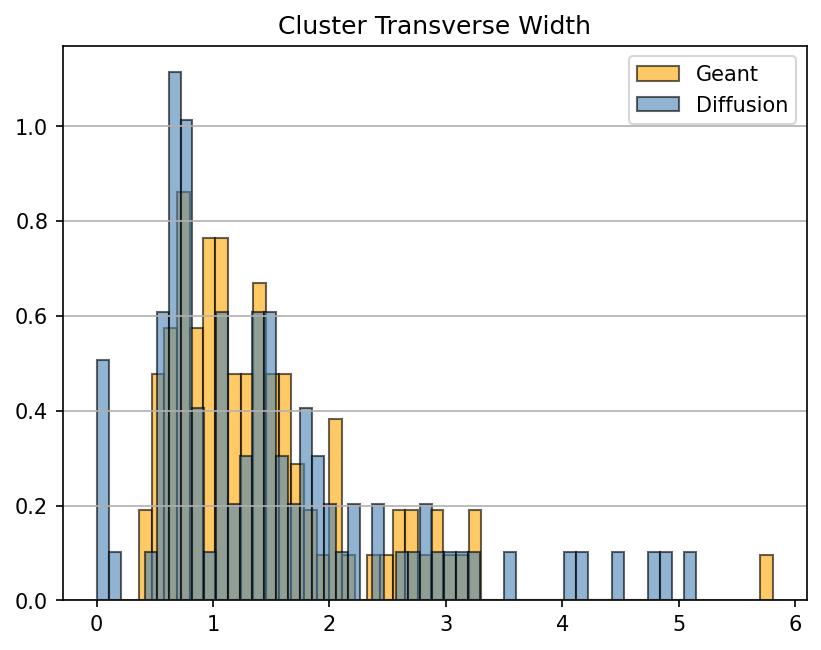

(0.767943676778612,
 0.8611545177011599,
 <Figure size 1200x1200 with 1 Axes>,
 <Figure size 1200x1200 with 1 Axes>)

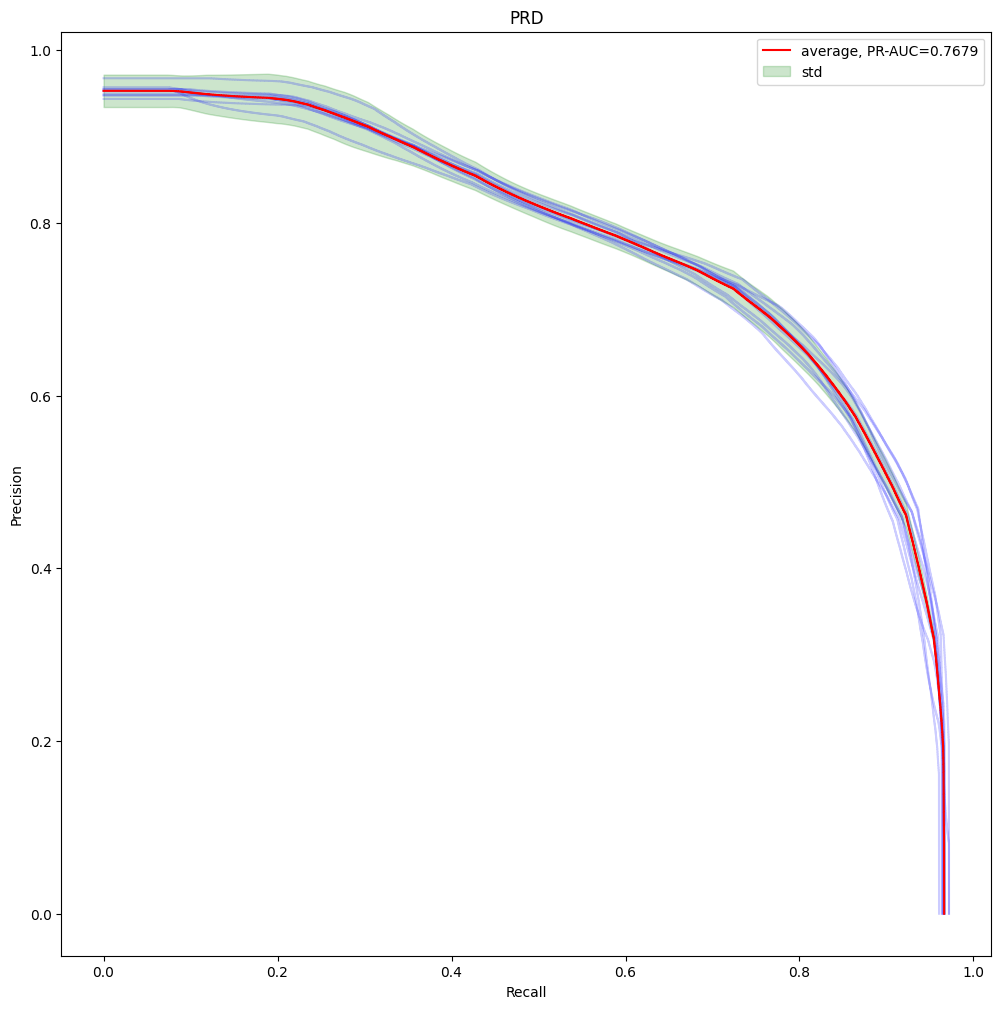

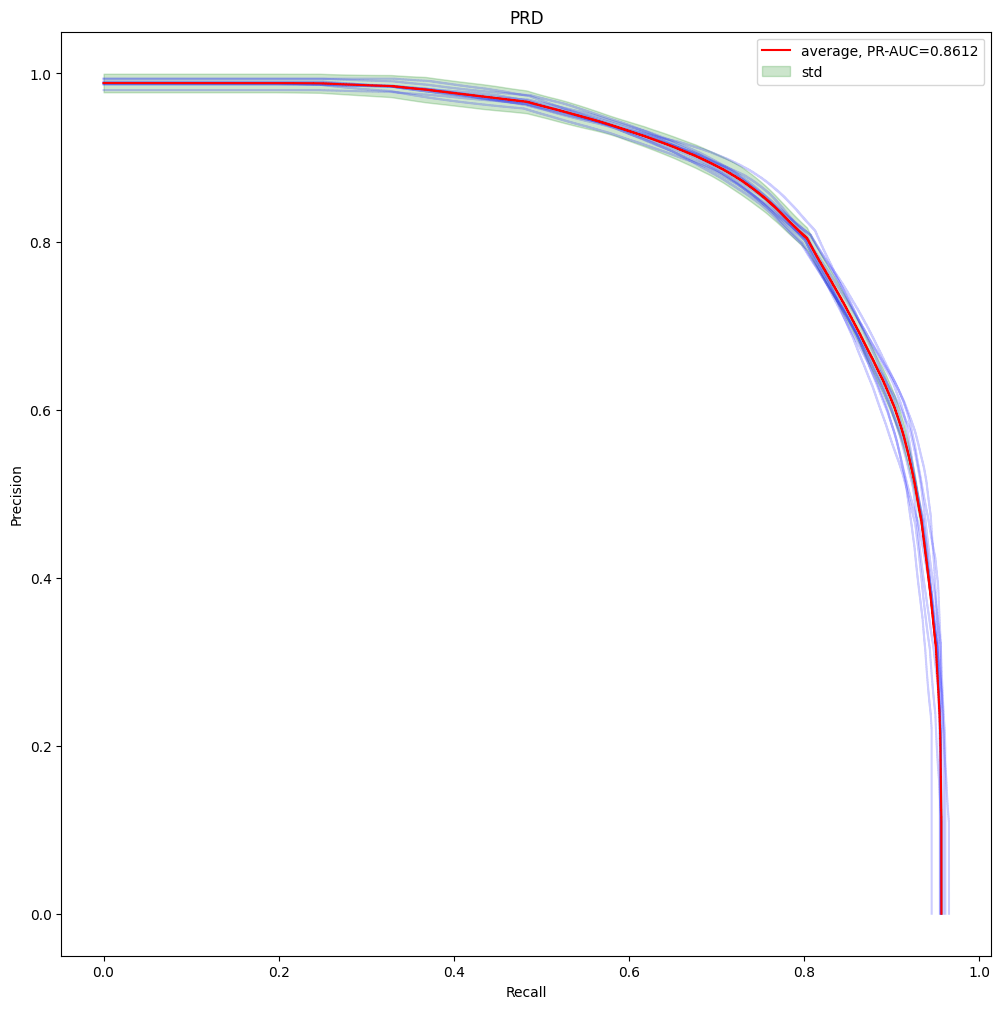

In [5]:
from evaluate import calc_metrics

calc_metrics(dm, val_loader, 3)

In [16]:
list(range(30, 120 + 1, 30))

[30, 60, 90, 120]

In [5]:
# dm.eval()
# with torch.no_grad():
#     sample = dm.sample_single(momentum[10], point[10], plot=True)

In [6]:
samples = dm.sample(momentum, point)

  0%|          | 0/100 [00:00<?, ?it/s]

In [9]:
from metrics.calogan_metrics import get_assymetry, get_shower_width

get_assymetry(energy.detach().numpy(), momentum.detach().numpy(), point.detach().numpy(), orthog=False)

array([[            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan, -6.46374540e+00,
                    nan, -1.96288348e+01, -2.84854754e+01,
        -2.41697861e+01, -2.65645651e+01, -2.19024495e+01,
        -1.80000000e+01, -9.96673231e+00, -1.00000000e+01,
                    nan, -1.00000000e+01,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan],
       [            nan,             nan,             nan,
                    nan,             nan,             nan,
                    nan,             nan,             nan,
        -1.50565021e+00, -2.00000004e+00, -4.20278911e+00,
        -1.29584265e+01, -1.98347050e+01, -2.75562160e+01,
        -2.97422886e+01, -2.78402711e+01, -1.58173139e+01,
        -1.44995907e+01, -1.40000000e+01, -1.00000000e+

In [9]:
def compare(idx=0, truncate=None):
    real, sampled = energy[idx].detach().numpy(), samples[idx].detach().numpy()
    vmin, vmax = min(real.min(), sampled.min()), max(real.max(), sampled.max())

    fig, axs = plt.subplots(1, 2, layout='constrained', sharex=True, sharey=True)
    sum1, sum2 = energy[idx].sum(), samples[idx].sum()
    im1 = axs[0].imshow(np.transpose(real, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[0].set(title=f'real {sum1:.2f}')
    if truncate:
        sampled[sampled < truncate] = 0
    im2 = axs[1].imshow(np.transpose(sampled, (1, 2, 0)), cmap='inferno', vmin=vmin, vmax=vmax)
    axs[1].set(title=f'generated {sum2:.2f}')
    fig.colorbar(im2, fraction=0.05)
    plt.show()

In [10]:
from metrics.calogan_metrics import get_physical_stats

embeds = get_physical_stats(samples.detach().numpy(), momentum.detach().numpy(), point.detach().numpy())
embeds.shape


(32, 120)

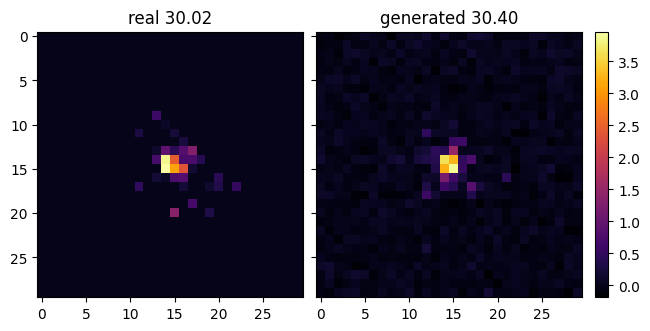

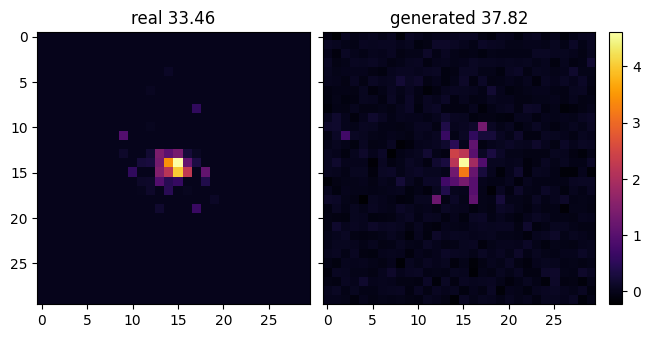

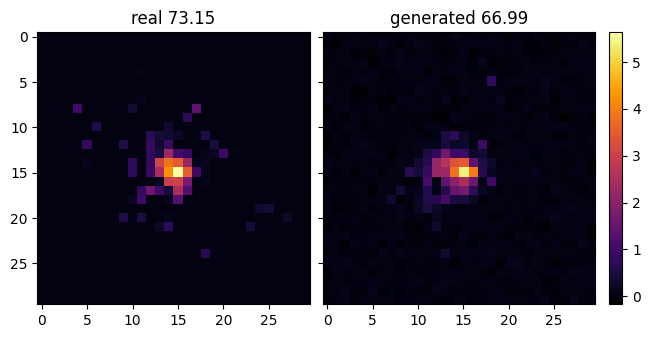

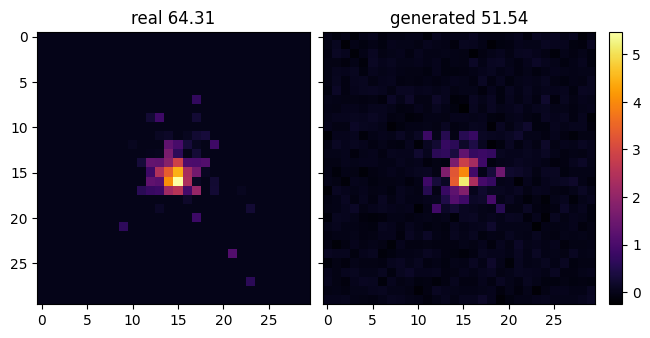

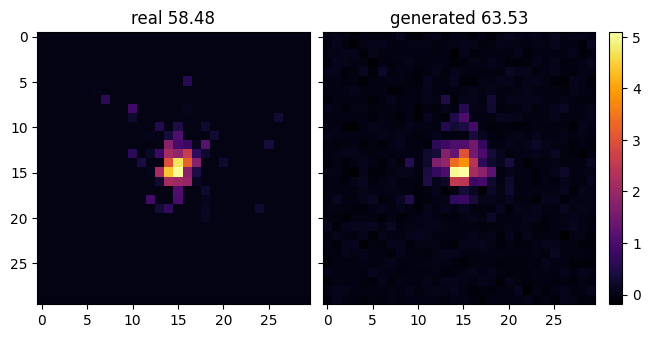

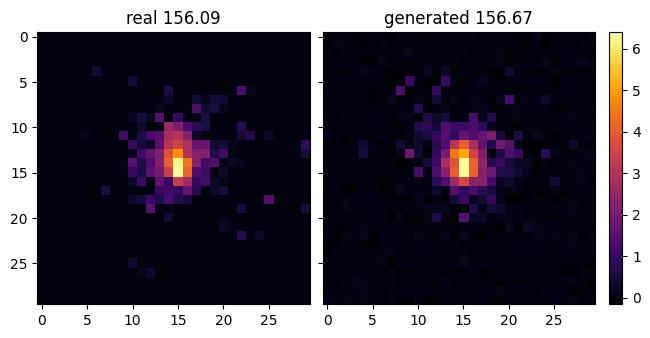

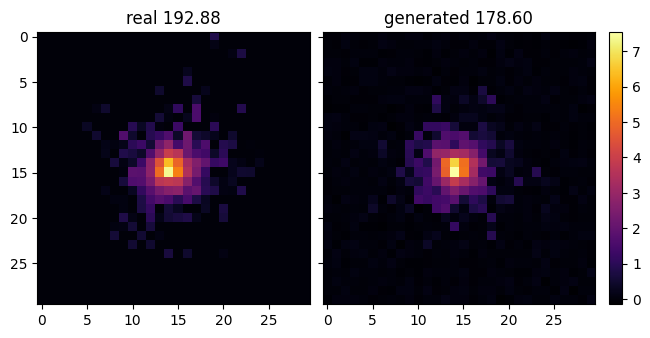

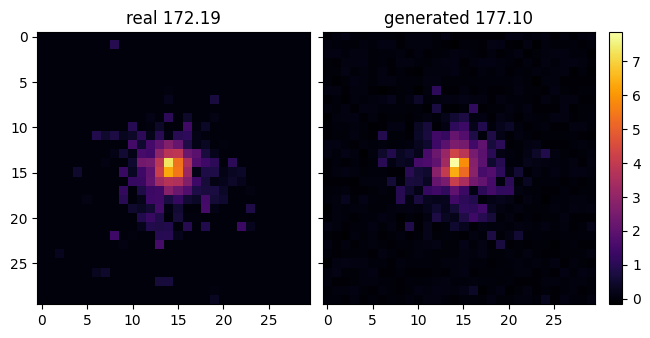

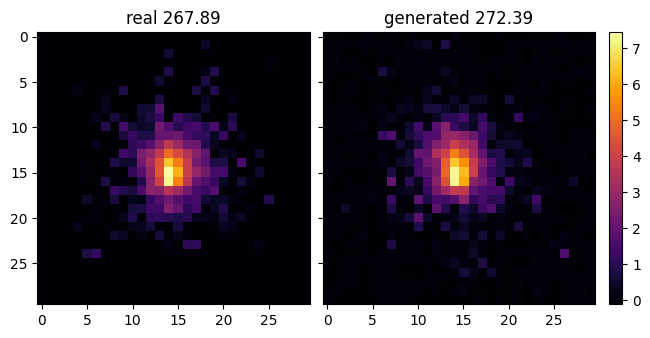

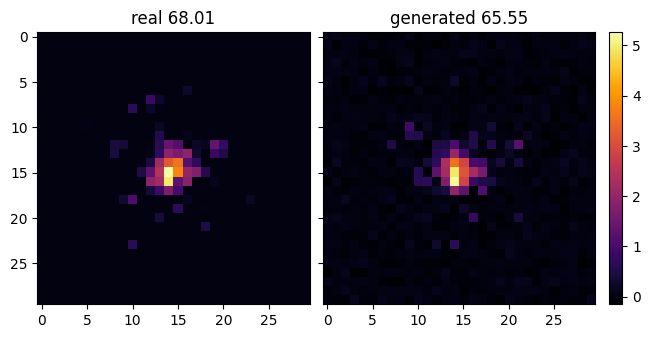

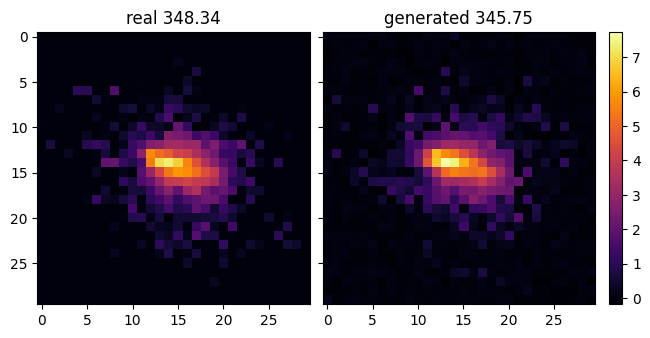

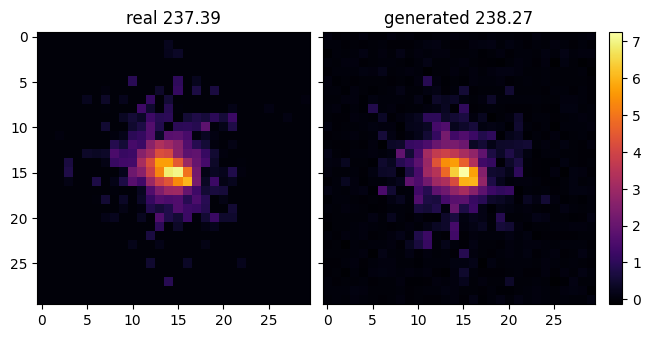

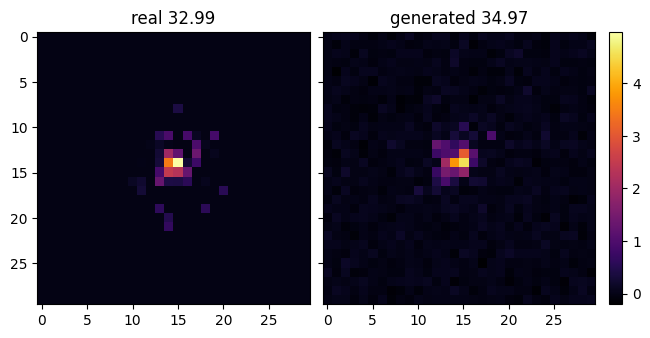

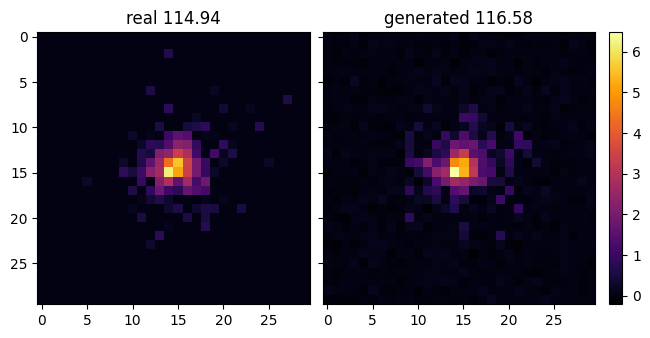

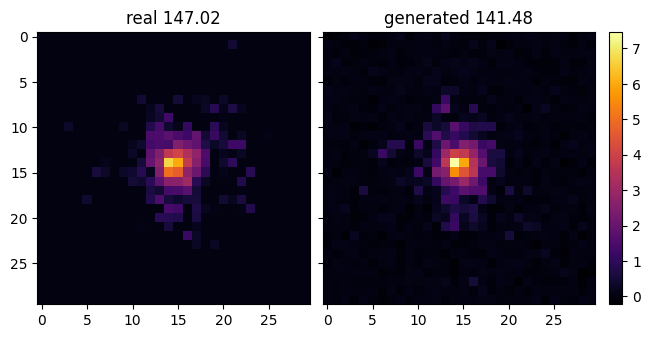

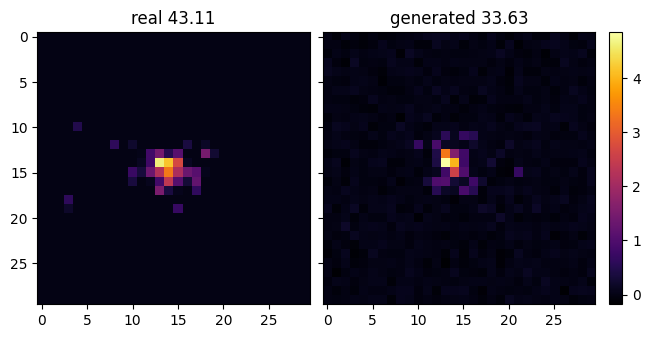

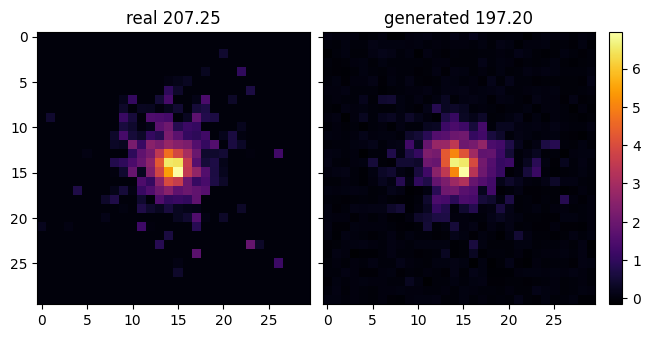

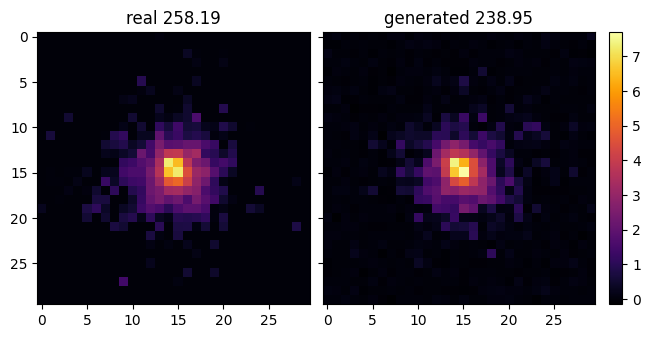

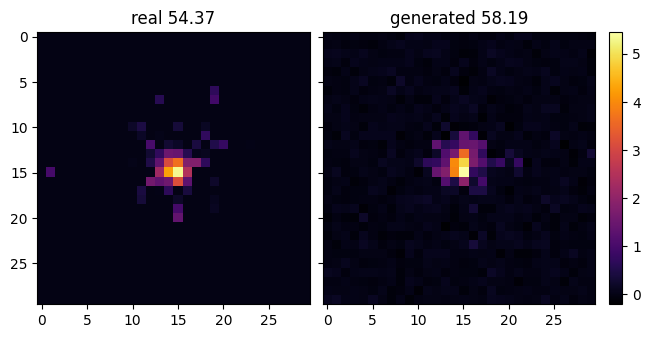

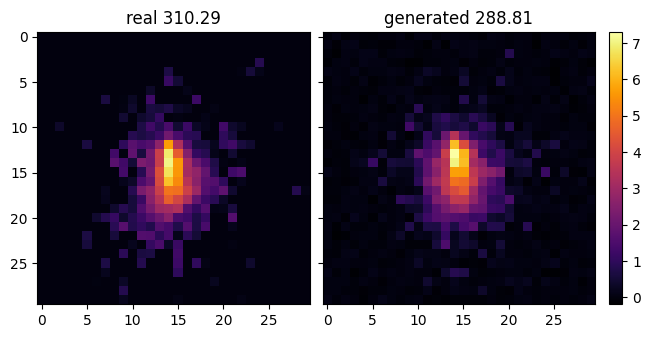

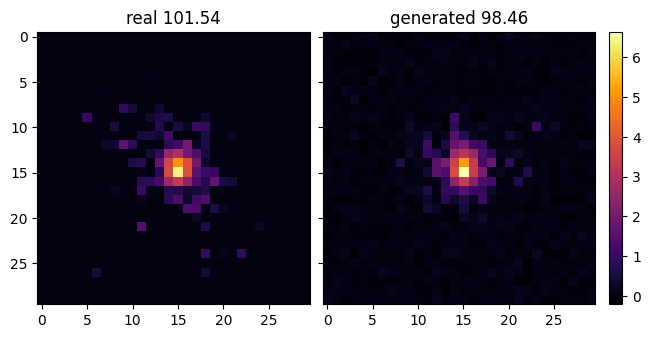

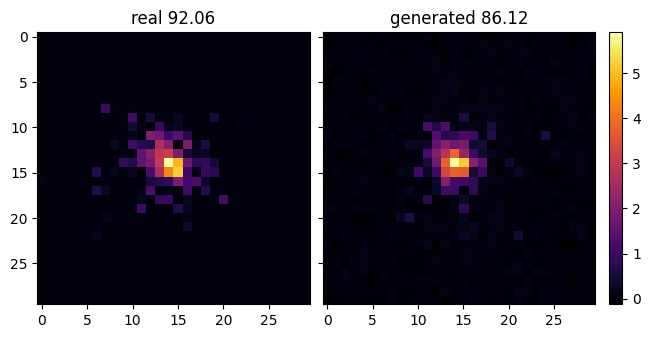

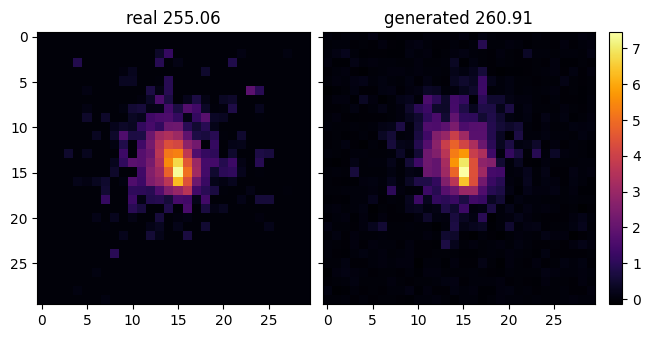

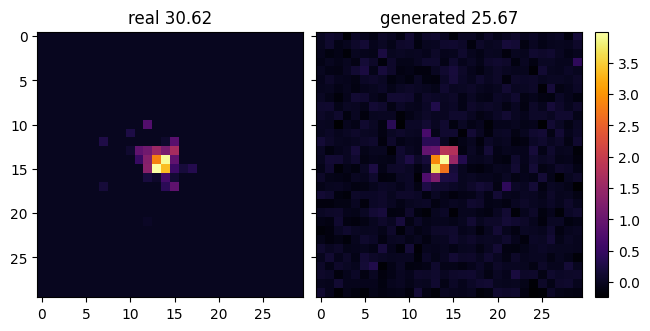

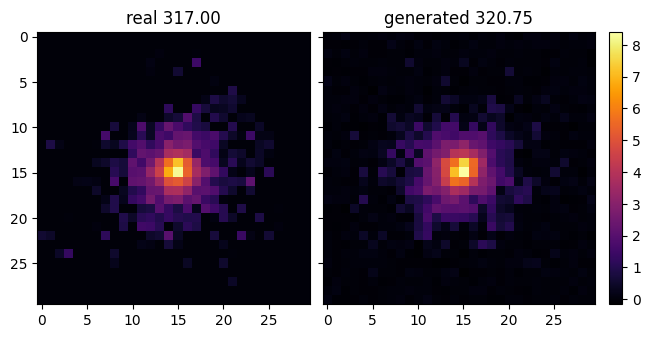

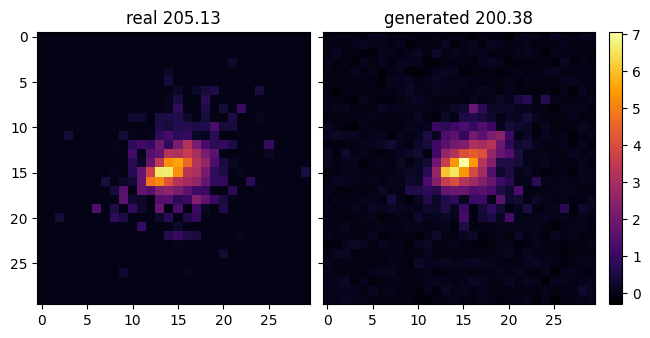

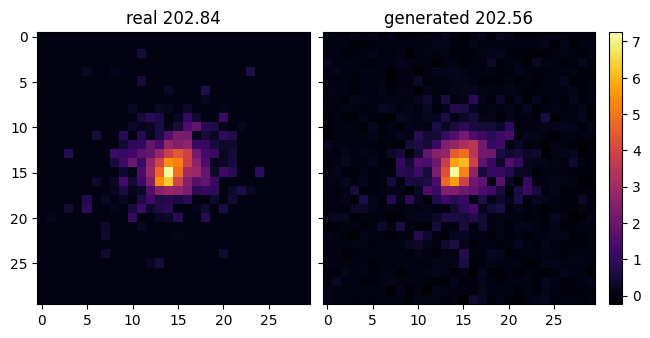

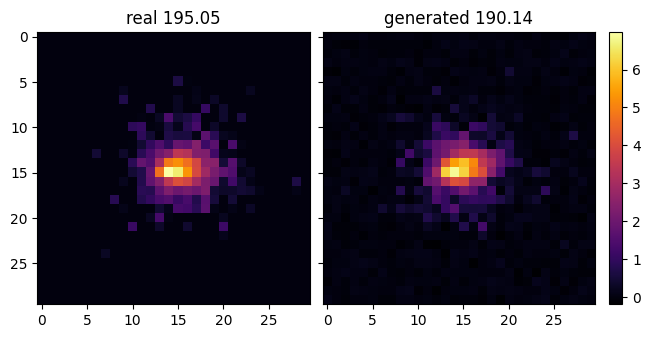

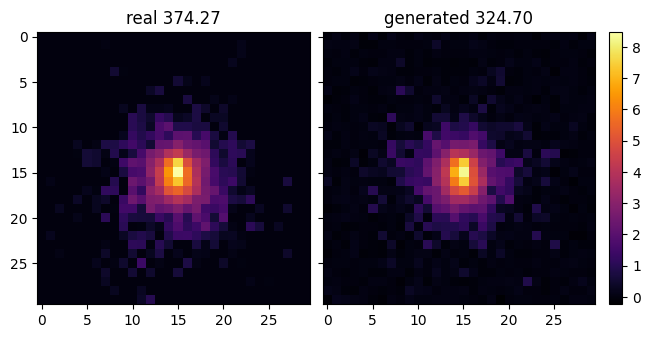

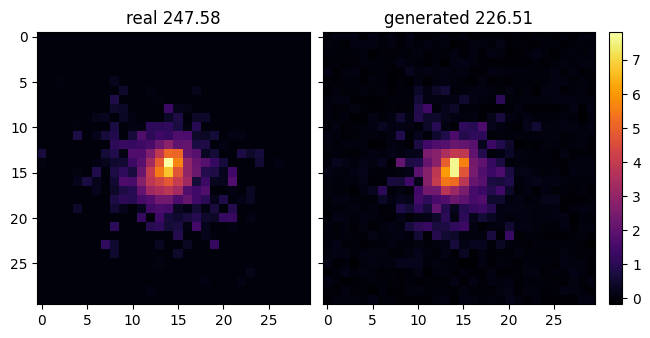

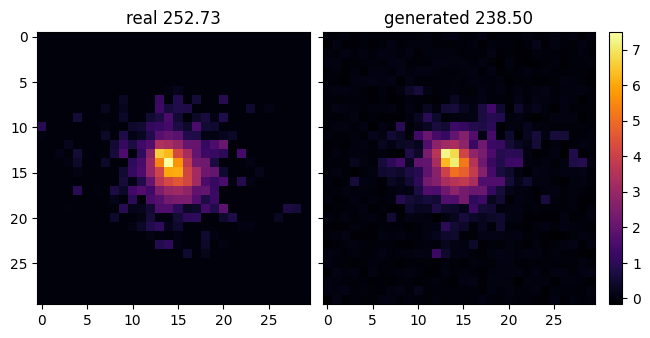

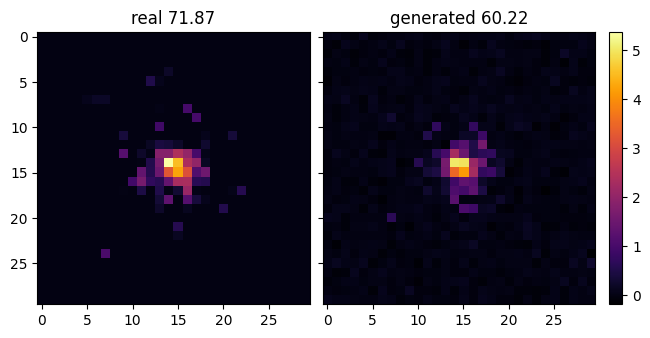

In [11]:
for i in range(32):
    compare(i)